In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_groq import ChatGroq
from duckduckgo_search import DDGS
from model import predict
from rag import retriver
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class SupportState(TypedDict):
    query: str
    result: str
    solved: Literal["yes","no"]
    next_agent: str
    final_answer: str

In [14]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

def choose_agent(state: SupportState):
    prompt = f"""Read user query and decide which agent to use.
    'rag' - for questions about company policies, refunds policy, return policy, offers.
    'web' - for company current status in market what is growth and insights of the company. 
    'generic_agent' - when user ask about there order, status, account related issue or payment related issue then use this.
    'escalate' - ONLY when user explicitly says 'talk to human' or 'speak to agent'
    Return only one word: rag, web, escalate or generic.
    user query: {state['query']}"""
    response = llm.invoke(prompt)
    return {"next_agent":response.content.strip().lower()}

def rag_agent(state: SupportState):
    docs = retriver.invoke(state["query"])
    return {"result": "\n".join([d.page_content for d in docs])}

def web_agent(state: SupportState):
    with DDGS() as ddgs:
        results = list(ddgs.text(state['query'], max_results=3))
    output = "\n".join([r['body'] for r in results])
    return {"result":output}

def escalate_agent(state: SupportState):
      return {"result": "My name is Kanhaiya and I'm here to solve your query. Please describe your issue."}


def responder(state: SupportState):
    print(f"{state['result']}\n\nDoes Your Query solved???")
    user_input = input("Type Here: ")
    if user_input.strip().lower() == "yes":
        print("Thanks For Your Patience.\n\nPlease Give us Feedback")
        state["solved"] = "yes"
    else:
        state["solved"] = "no"
    return state

def generic_agent(state: SupportState):
    response = predict(state['query'])
    return {"result":response}

def agent_router(state: SupportState):
    return state["next_agent"]

def router(state: SupportState):
    if state["solved"] == 'yes':
        return "yes"
    else:
        return "no"

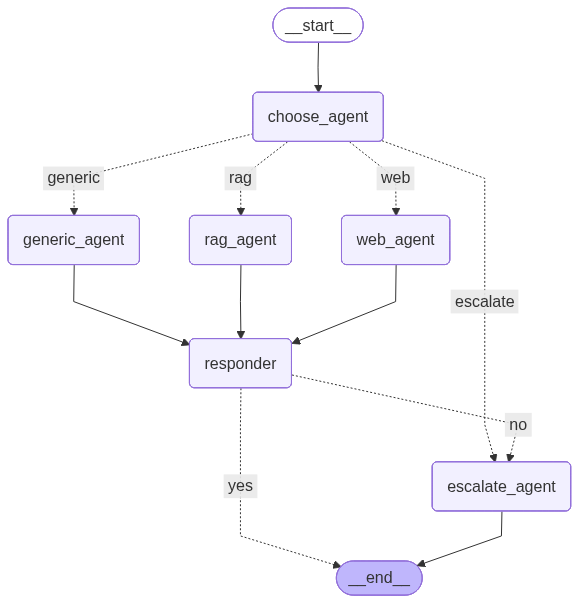

In [15]:
graph = StateGraph(SupportState)
graph.add_node("choose_agent",choose_agent)
graph.add_node("rag_agent",rag_agent)
graph.add_node("web_agent",web_agent)
graph.add_node("escalate_agent",escalate_agent)
graph.add_node("generic_agent",generic_agent)
graph.add_node("responder",responder)

graph.add_edge(START,"choose_agent")
graph.add_conditional_edges("choose_agent",agent_router,{"web":"web_agent","rag":"rag_agent","escalate":"escalate_agent","generic":"generic_agent"})
graph.add_conditional_edges("responder",router,{"yes":END,"no":"escalate_agent"})
graph.add_edge("rag_agent", "responder")
graph.add_edge("web_agent", "responder")
graph.add_edge("generic_agent","responder")
graph.add_edge("escalate_agent", END)

workflow = graph.compile()
workflow

In [18]:
workflow.invoke({
    "query": "my order didn't arrived",
    "result": "",
    "solved": "no",
    "next_agent": "",
    "final_answer": ""
})

Bot: I apologize for the inconvenience. Please share your order ID and we'll arrange a full refund or refund.


Does Your Query solved???


{'query': "my order didn't arrived",
 'result': "My name is Kanhaiya and I'm here to solve your query. Please describe your issue.",
 'solved': 'no',
 'next_agent': 'generic',
 'final_answer': ''}